# L12: Transfer Learning

In L2, you ran `learn.fine_tune(3)` with fastai and got a working pet classifier. Magic. No understanding. In L9, you built an MLP on bird images from scratch - 25 million parameters, topped out at ~55%. In L10, you applied regularization techniques to CIFAR-10 and pushed the MLP to its ceiling. In L11, you built a CNN from scratch on the birds - 394K parameters, reached ~81%.

Each lesson revealed something new. L9 showed that the pipeline matters. L10 showed that tuning matters. L11 showed that architecture matters. This lesson reveals the final piece: **starting weights matter most of all.**

What happens when we take a CNN that someone already trained on ~1.2 million images and adapt it to our birds? The answer: dramatically better accuracy with minimal training. With just 2,565 trainable parameters (vs 25 million in L9), we can match or exceed everything we've built so far. And now you'll understand exactly what's happening - because you built all the pieces in L9-L11.

Object detection (YOLO) is covered in a separate notebook: `object_detection.ipynb`.

<details>
<summary>Lecture Notes (click to expand)</summary>

See `lecture_notes/12_finetuning_and_deployment/lecture_notes_v2_2026_04_06.md` for the full lecture notes, terminology, and resources.

</details>

In [93]:
# === Setup and plotting helpers (run this first, then collapse) ===

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


def plot_feature_hierarchy():
    """Layer cake diagram showing what each CNN layer learns."""
    fig, ax = plt.subplots(figsize=(12, 4))
    layers = [
        ('Conv 1-2', 'Edges, gradients,\ncolor blobs', '#4CAF50', 'Universal'),
        ('Conv 3-5', 'Textures, patterns,\nrepeated structures', '#2196F3', 'Mostly universal'),
        ('Conv 6+', 'Parts, shapes,\nobject components', '#FF9800', 'Task-specific'),
        ('FC Head', '1000 ImageNet\nclass predictions', '#F44336', 'Replace this'),
    ]
    for i, (name, desc, color, note) in enumerate(layers):
        rect = mpatches.FancyBboxPatch((i * 2.8 + 0.1, 0.2), 2.5, 2.0,
                                        boxstyle="round,pad=0.1", facecolor=color, alpha=0.8)
        ax.add_patch(rect)
        ax.text(i * 2.8 + 1.35, 1.6, name, ha='center', va='center', fontsize=12, fontweight='bold', color='white')
        ax.text(i * 2.8 + 1.35, 0.9, desc, ha='center', va='center', fontsize=9, color='white')
        ax.text(i * 2.8 + 1.35, -0.15, note, ha='center', va='center', fontsize=9, fontstyle='italic', color='gray')
        if i < len(layers) - 1:
            ax.annotate('', xy=(i * 2.8 + 2.7, 1.2), xytext=(i * 2.8 + 2.9, 1.2),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=2))
    ax.set_xlim(-0.2, 11.5)
    ax.set_ylim(-0.5, 2.8)
    ax.set_title('What Pretrained CNN Layers Have Learned', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def plot_frozen_layers(title='Feature Extraction vs Fine-Tuning'):
    """Side-by-side visualization of frozen vs trainable layers."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    layer_names = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'fc (head)']
    colors_fe = ['#BDBDBD'] * 5 + ['#4CAF50']
    axes[0].barh(layer_names, [1]*6, color=colors_fe, edgecolor='white', height=0.6)
    axes[0].set_title('Feature Extraction\n(freeze backbone, train head only)', fontsize=11, fontweight='bold')
    axes[0].set_xlim(0, 1.5)
    axes[0].set_xticks([])
    colors_ft = ['#C8E6C9', '#A5D6A7', '#81C784', '#66BB6A', '#4CAF50', '#2E7D32']
    axes[1].barh(layer_names, [1]*6, color=colors_ft, edgecolor='white', height=0.6)
    axes[1].set_title('Fine-Tuning\n(train all, lower LR for early layers)', fontsize=11, fontweight='bold')
    axes[1].set_xlim(0, 1.5)
    axes[1].set_xticks([])
    frozen_patch = mpatches.Patch(color='#BDBDBD', label='Frozen')
    train_patch = mpatches.Patch(color='#4CAF50', label='Trainable')
    fig.legend(handles=[frozen_patch, train_patch], loc='lower center', ncol=2, fontsize=11)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


def plot_training_curves(history, title=''):
    """Dual plot: loss + accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train Loss', color='#2196F3')
    axes[0].plot(history['val_loss'], label='Val Loss', color='#FF9800')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss' if title else 'Loss Curves')
    axes[0].legend()
    axes[1].plot([a * 100 for a in history['train_acc']], label='Train Acc', color='#2196F3')
    axes[1].plot([a * 100 for a in history['val_acc']], label='Val Acc', color='#4CAF50')
    best_val = max(history['val_acc']) * 100
    axes[1].axhline(y=best_val, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_val:.1f}%')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy' if title else 'Accuracy Curves')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_comparison_table(results, title='Model Comparison'):
    """Horizontal bar chart comparing model accuracies."""
    names = list(results.keys())
    accs = [v * 100 for v in results.values()]
    colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0', '#00BCD4']
    fig, ax = plt.subplots(figsize=(10, max(3, len(names) * 0.8)))
    bars = ax.barh(names, accs, color=colors[:len(names)], height=0.5, edgecolor='white')
    ax.set_xlabel('Validation Accuracy (%)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{acc:.1f}%',
                va='center', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Heatmap confusion matrix."""
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_lr_per_group(group_names, lrs, title='Discriminative Learning Rates'):
    """Bar chart showing LR per parameter group."""
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = plt.cm.Greens([0.3 + 0.7 * i / len(group_names) for i in range(len(group_names))])
    ax.bar(group_names, lrs, color=colors, edgecolor='white', width=0.6)
    ax.set_ylabel('Learning Rate')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    for i, lr in enumerate(lrs):
        ax.text(i, lr * 1.5, f'{lr:.0e}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def plot_first_layer_filters(model, title='First Layer Filters (conv1)'):
    """Visualize conv1 filters as a grid of small RGB images."""
    filters = model.conv1.weight.data.cpu().clone()
    n_filters = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        if i < n_filters:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Helpers loaded!")

Helpers loaded!


All imports for the notebook.

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import numpy as np
from pathlib import Path
from PIL import Image
import time
import warnings
import urllib.request
import zipfile

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__}")

PyTorch 2.9.1+cu128


Set the data path and detect GPU. Download the bird dataset if needed.

In [95]:
# Change this path if running locally with a different folder structure
DATA_DIR = Path("../../../../data")

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")

# Download bird dataset (same as L9/L11)
BIRD_DIR = DATA_DIR / "bird_data"
if not BIRD_DIR.exists():
    url = "https://github.com/UA-classroom/ua-datasets/releases/download/datasets/bird_data.zip"
    zip_path = DATA_DIR / "bird_data.zip"
    print("Downloading bird dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    zip_path.unlink()
    print("Done!")

CLASS_NAMES = sorted([d.name for d in BIRD_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {CLASS_NAMES} ({NUM_CLASSES} classes)")

Using cuda
Classes: ['eagle', 'flamingo', 'owl', 'parrot', 'penguin'] (5 classes)


## Part 1: Transfer Learning Theory

Before we write any training code, we need to understand what we're doing and why.

**Transfer learning** means taking a model that was trained on one task and reusing it as the starting point for a different task. Instead of initializing weights randomly and learning everything from scratch, we start from weights that already encode useful knowledge about the world.

This is the single most important practical technique in modern deep learning. Almost nobody trains image models from scratch anymore - it's slower, requires vastly more data, and produces worse results. The same principle applies far beyond images: GPT and BERT are pretrained language models that get fine-tuned for specific text tasks. Whisper is a pretrained audio model. CLIP was pretrained on image-text pairs. The pattern is always the same: pretrain on a massive general dataset, then adapt to your specific problem with much less data.

In this lesson we focus on **image classification**, where transfer learning is most mature. We take a CNN pretrained on ImageNet and adapt it to classify our birds. But the concepts - freezing layers, replacing heads, discriminative learning rates, two-phase training - apply to any domain where pretrained models exist.

<img src="../../../../images/transfer_learning_concept.jpg" alt="Transfer learning concept" width="700">

### Transfer Learning is Everywhere

We're using CNNs on images in this lesson, but transfer learning is arguably even more important in NLP. Every time you use ChatGPT, Claude, or a fine-tuned BERT model, you're using transfer learning. The pattern is always the same:

1. **Pretrain** a large model on a massive general dataset (ImageNet for vision, internet text for LLMs)
2. **Adapt** it to your specific task with much less data

| Domain | Pretrained on | What it learned | Fine-tune for |
|---|---|---|---|
| **Images (this lesson)** | ImageNet (~1.2M photos) | Edges, textures, shapes, objects | Your classification task |
| **Text / LLMs** | Internet text (trillions of tokens) | Grammar, facts, reasoning, style | Chatbots, classification, summarization |
| **Audio** | Speech recordings | Sound patterns, phonemes, languages | Your transcription or voice task |
| **Code** | GitHub repositories | Syntax, patterns, libraries | Code completion for your codebase |

The techniques we learn here - freezing layers, replacing heads, using different learning rates - have direct equivalents in LLM fine-tuning. When you fine-tune GPT or Llama for a specific task, you're doing the same thing: keeping most pretrained knowledge intact while adapting the model to your needs. The main difference is scale: CNN fine-tuning involves millions of parameters. LLM fine-tuning involves billions, which is why techniques like **LoRA** (Low-Rank Adaptation) exist - they make fine-tuning feasible without needing hundreds of gigabytes of GPU memory. We'll explore LLM fine-tuning in later lessons.

For now, we focus on image CNNs where the concepts are easier to visualize and experiment with.

### What Pretrained Layers Know

**ImageNet** is the dataset that changed deep learning. ~1.2 million images across 1,000 classes - everything from dog breeds to musical instruments to food. Researchers at universities and companies train their models on ImageNet and then share the weights publicly. When we say "pretrained model," we almost always mean "trained on ImageNet."

Why is this useful to us? Because a CNN trained on ImageNet has learned a hierarchy of visual features through gradient descent. Each layer has specialized:

<img src="../../../../images/feature_hierarchy.jpg" alt="What each CNN layer learns" width="700">

In PyTorch, accessing this entire pretrained hierarchy is one line:

In [96]:
# One line to load a CNN trained on 1.2 million images
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print(f"Loaded ResNet-18: {sum(p.numel() for p in model.parameters()):,} pretrained parameters")

Loaded ResNet-18: 11,689,512 pretrained parameters


That hierarchy is already inside any pretrained model we load. Let's verify:

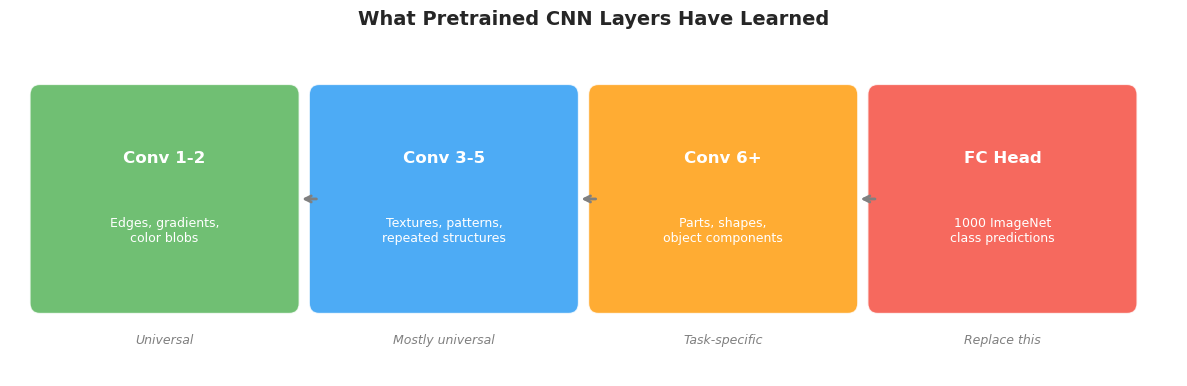

In [97]:
plot_feature_hierarchy()

The key insight: early layers are universal. A top-edge detector learned from dog photos works equally well on bird photos, x-rays, or satellite images. Edges are edges regardless of what you're classifying.

This is why training from scratch on 950 bird images is wasteful. The model has to re-discover that edges exist, that textures matter, that shapes have meaning - knowledge that millions of images have already taught. Transfer learning lets us skip all of that and start from "I already understand the visual world, just tell me which classes you care about."

This is also why the CNN from L11 (trained from scratch) needed careful architecture tuning, batch normalization, and 1cycle scheduling just to reach 81%. A pretrained model gets there in one epoch.

### Two Strategies: Feature Extraction vs Fine-Tuning

There are two ways to use a pretrained model. Both replace the final classification head, but they differ in how much of the backbone you update.

<img src="../../../../images/extraction_vs_finetuning.jpg" alt="Feature extraction vs fine-tuning" width="700">

**Feature extraction** (also called **linear probing**) freezes the entire backbone. Only the new head trains. The backbone acts as a fixed feature extractor - it transforms raw pixels into a 512-dimensional feature vector, and the head learns a simple mapping from features to classes. This is fast (few trainable parameters), has low risk of overfitting, and works well when your data is similar to ImageNet.

**Fine-tuning** trains everything, but with a lower learning rate for early layers. This is more flexible - the backbone can adapt its features to your specific domain. But it risks destroying useful pretrained weights if the learning rate is too high. The pretrained model is in a good region of the loss landscape; aggressive updates can push it out.

The practical difference is stark: feature extraction trains in seconds with near-zero overfitting risk. Fine-tuning trains in minutes and can overfit on small datasets. On our bird dataset, we'll see that feature extraction alone gets remarkable results - which is itself an important lesson about when the simpler approach is sufficient.

This same approach is used constantly in NLP. When you use a pretrained BERT model and add a classification head for sentiment analysis, that's feature extraction - BERT's transformer layers are frozen, and only the head learns your task. Research shows that freezing the first 8 layers of BERT barely affects performance on many tasks, because those early layers encode general language understanding that transfers well. The parallel to vision is direct: early CNN layers learn universal edges, early BERT layers learn universal grammar.

In code, the difference is just a few lines:

The matplotlib version below shows the same concept with specific ResNet-18 layer names:

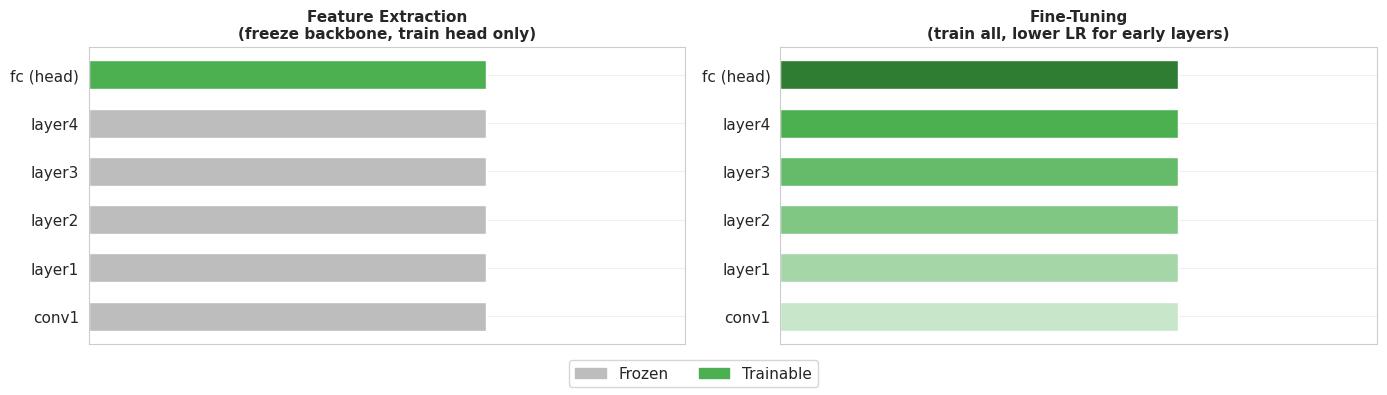

In [98]:
plot_frozen_layers()

And the code to do this in PyTorch:

In [99]:
# Feature extraction: freeze everything, replace head
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(512, 5)  # only this layer trains

# Fine-tuning: keep everything trainable, lower LR
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 5)  # everything trains, but use lr=1e-4 not 1e-3

**When to use which - a practical heuristic:**

The choice depends on two things: how much data you have, and how similar it is to ImageNet.

**Small dataset (<1,000 images), similar domain** (everyday photos, animals, objects) - feature extraction. Freeze the backbone, train only the head. Fast, almost no overfitting risk.

**Medium dataset (1,000-10,000 images), moderate domain shift** (different lighting, angles, image style) - staged fine-tuning. Train head first, then unfreeze with lower LR. The two-phase recipe.

**Large dataset (10,000+ images), or very different domain** (x-rays, satellite imagery, microscopy) - full fine-tuning, possibly with discriminative LR. Early layers might still help (edges are edges everywhere), but later layers need significant adaptation.

**When transfer learning can hurt:** if the source domain is very different from your target and your dataset is small, the pretrained features might actually be counterproductive. This is called **negative transfer**. A model pretrained on natural photos might encode biases (color distributions, object scales, background patterns) that mislead it on medical scans. In such cases, look for a domain-specific pretrained model, or consider training from scratch with heavy augmentation.

### Why Pretrained Beats From-Scratch

Our bird dataset has ~950 images. ImageNet has ~1.2 million. A model trained from scratch on 950 images must learn everything: edge detection, texture recognition, shape understanding, and bird-part identification. A pretrained model already knows the first three - it only needs to learn "which combinations mean eagle vs owl."

| | From scratch | Pretrained |
|---|---|---|
| Edge detection | Must learn | Already knows |
| Texture patterns | Must learn | Already knows |
| Shape recognition | Must learn | Already knows |
| Bird-specific features | Must learn | Must learn |
| Training data needed | A lot | Very little |

Think of it this way: teaching someone to identify birds is much easier if they already know what feathers, beaks, and wings look like. You don't need to teach them what a texture is - you just need to teach them what distinguishes an eagle from a flamingo. That's what pretrained weights give you.

The exact same logic applies to language models. GPT was pretrained on billions of words of internet text. It already knows grammar, facts, reasoning patterns, and writing styles. Fine-tuning it for sentiment analysis or customer support doesn't require re-learning English - it just needs to learn the specific task. That's why you can fine-tune an LLM with a few hundred examples and get strong results.

### The Two-Phase Training Recipe

The standard approach that works in practice combines both strategies sequentially:

**Phase 1 - Train the head (2-5 epochs).** Freeze the backbone. Replace the classification head with a new one for your classes. Train with a moderate learning rate (e.g. 1e-3). The head learns to map pretrained features to your classes.

Why train the head first? Because a randomly initialized head produces random gradients. If you unfreeze the backbone immediately, those random gradients from the head flow backward through the entire network, potentially corrupting the useful pretrained features. Training the head first gives it sensible weights, so when you unfreeze, the gradients flowing backward are meaningful.

**Phase 2 - Fine-tune everything (5-15 epochs).** Unfreeze all layers. Use a much lower learning rate (e.g. 1e-5 to 1e-4). The backbone now receives gradients from a trained head, so it can adapt meaningfully. Early stopping when validation performance plateaus.

This is what fastai's `learn.fine_tune()` does behind the scenes. Now you'll implement it yourself.

<img src="../../../../images/two_phase_recipe.jpg" alt="Two-phase training recipe" width="700">

This two-phase pattern appears across all of deep learning. When you fine-tune an LLM, the same logic applies: first train a task-specific head (or adapter layers) while keeping the base model frozen, then optionally unfreeze deeper layers with a lower learning rate. The scale is different (billions of parameters instead of millions), but the principle is identical.

### Discriminative Learning Rates

When fine-tuning, not all layers should learn at the same speed. Think about what each layer has learned:

Early layers learned edges and color gradients. These are universal - they're as useful for birds as they were for ImageNet. Big updates would destroy good features for no benefit. Use a tiny learning rate (1e-5).

Middle layers learned textures and patterns. These are mostly universal but might benefit from slight adaptation. Use a moderate rate (1e-4).

Late layers learned high-level concepts specific to ImageNet's 1,000 classes. These need the most adaptation for your task. Use a higher rate (1e-3).

The new head was randomly initialized. It needs to learn everything from scratch. Use the highest rate (1e-2).

This gradient of learning rates - slow for early layers, fast for late layers - is called **discriminative learning rates**. It's one of the key insights from the fastai course and it appears in the original ULMFiT paper (Howard & Ruder, 2018) that popularized modern transfer learning.

Interestingly, ULMFiT was originally designed for text classification, not vision. It proved that discriminative LR and gradual unfreezing work for NLP - the same insights then carried back to vision.

For modern LLMs with billions of parameters, even discriminative learning rates aren't enough - you can't fit a 70B model in GPU memory for full fine-tuning. This led to **LoRA (Low-Rank Adaptation)**: instead of updating full weight matrices, you freeze everything and inject small trainable low-rank matrices into specific layers. A LoRA adapter might be just 10-50MB, while the base model is 30GB+. It's the same principle as our frozen backbone approach, but taken further - you don't even replace the head, you add small learnable "patches" throughout the network.

<img src="../../../../images/discriminative_lr.jpg" alt="Discriminative learning rates" width="700">

The PyTorch implementation uses **parameter groups** - each group gets its own learning rate:

Here's the same idea as a chart with concrete values for ResNet-18:

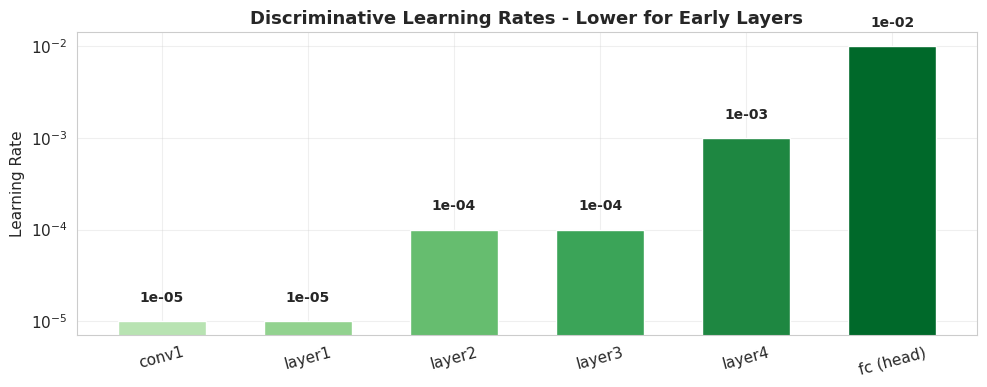

In [100]:
plot_lr_per_group(
    ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'fc (head)'],
    [1e-5, 1e-5, 1e-4, 1e-4, 1e-3, 1e-2],
    title='Discriminative Learning Rates - Lower for Early Layers'
)

And the code to set this up in PyTorch:

In [101]:
# Each layer group gets a different learning rate
optimizer = optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},   # early: preserve
    {'params': model.layer2.parameters(), 'lr': 1e-4},   # middle: adapt slightly  
    {'params': model.layer3.parameters(), 'lr': 1e-3},   # late: adapt more
    {'params': model.fc.parameters(),     'lr': 1e-2},   # head: learn from scratch
])
print(f"Optimizer has {len(optimizer.param_groups)} parameter groups with different LRs")

Optimizer has 4 parameter groups with different LRs


## Part 2: Fine-Tuning in Practice

Time to implement everything from Part 1. The pattern is always the same:

1. Load a pretrained model
2. Replace the classification head for your number of classes
3. Choose a strategy (freeze backbone, fine-tune, or two-phase)
4. Train with appropriate learning rates

We start with the bird dataset from L9 and L11 to establish the core pattern. The results will be dramatic but also reveal an important lesson: when the task is easy enough, the simplest approach wins. Then we move to a harder task (Flowers102) where the choice of strategy and pretraining source actually matters.

### Data Loading with ImageNet Normalization

In L9, we computed normalization statistics from our bird images. For transfer learning, we use **ImageNet statistics** instead. Why?

The pretrained weights were calibrated during training to expect inputs normalized with ImageNet's mean and standard deviation. Every convolution filter, every batch normalization layer, every learned threshold in the network assumes the input values fall in a specific range. If you normalize differently, you're feeding the model values it has never seen - like speaking French to someone trained on English. The words (pixels) might be similar, but the distribution is wrong.

This is one of the most common transfer learning bugs: using the wrong normalization and wondering why accuracy is bad.

The ImageNet normalization values are well-known constants. You can also get them programmatically from the weights object:

```python
weights = models.ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()  # returns the full transform pipeline
```

We'll use the explicit constants below since they're clearer for learning.

In [102]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

full_dataset = datasets.ImageFolder(BIRD_DIR, transform=train_transforms)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size], generator=generator)
val_dataset.dataset = datasets.ImageFolder(BIRD_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Classes: {full_dataset.classes}")

Training: 755 images
Validation: 189 images
Classes: ['eagle', 'flamingo', 'owl', 'parrot', 'penguin']


Notice `RandomResizedCrop(224)` for training and `Resize(256) + CenterCrop(224)` for validation. The 224x224 size matches what ResNet was trained on. In L9, we used 128x128 - pretrained models expect their original resolution.

### What Pretrained ResNet-18 Already Knows

Let's load a pretrained ResNet-18 and look inside. This model has been trained on ImageNet (~1.2M images, 1,000 classes). It knows a lot about the visual world.

In [103]:
# Load pretrained ResNet-18
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

The model is a stack of residual blocks (same concept from L11) ending with an `fc` layer that maps 512 features to 1000 ImageNet classes. That `fc` layer is the head we'll replace.

Notice `AdaptiveAvgPool2d(output_size=(1, 1))` right before the FC layer. This pooling layer dynamically adjusts its window size to always output a 1x1 spatial map, regardless of input image size. This means ResNet can accept images of any size - the adaptive pooling ensures exactly 512 features reach the FC layer.

Let's visualize what the first convolutional layer has learned:

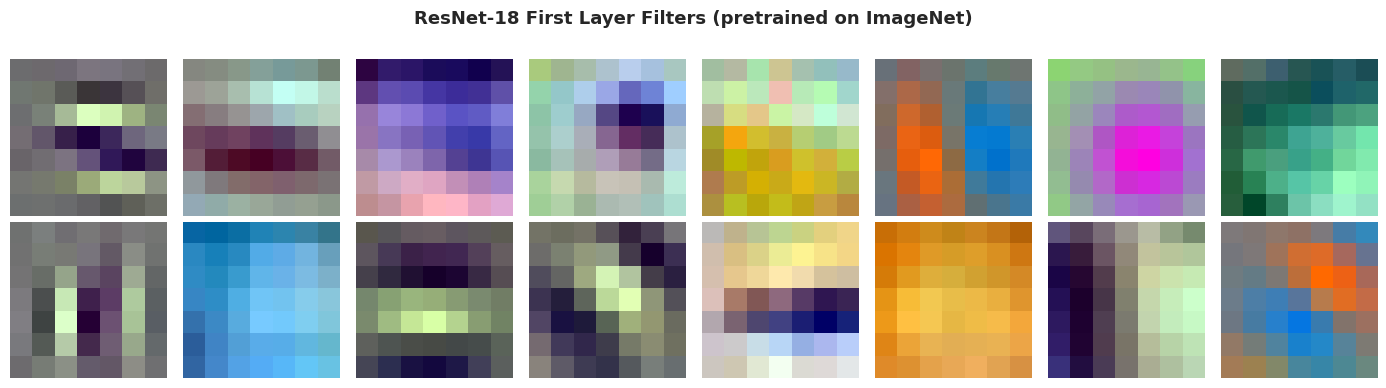

In [104]:
plot_first_layer_filters(resnet, title='ResNet-18 First Layer Filters (pretrained on ImageNet)')

These filters look like oriented edge detectors, color detectors, and gradient detectors. Compare this to L11 where we hand-crafted edge kernels - the network learned similar things automatically from ~1.2 million images.

How many parameters does this model have?

In [105]:
total_params = sum(p.numel() for p in resnet.parameters())
fc_params = sum(p.numel() for p in resnet.fc.parameters())
print(f"Total parameters:  {total_params:,}")
print(f"FC head parameters: {fc_params:,}")
print(f"Backbone parameters: {total_params - fc_params:,}")
print(f"\nThe head is {fc_params/total_params*100:.1f}% of the model")

Total parameters:  11,689,512
FC head parameters: 513,000
Backbone parameters: 11,176,512

The head is 4.4% of the model


Let's run a bird image through the pretrained model. ImageNet has many bird-related classes (bald eagle, jay, flamingo, etc.), so it should recognize our birds - just with ImageNet class names, not our 5-class labels.

In [106]:
# Run inference with ImageNet labels
resnet.eval()
resnet = resnet.to(device)

IMAGENET_LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
import json as _json, urllib.request
with urllib.request.urlopen(IMAGENET_LABELS_URL) as response:
    imagenet_labels = _json.loads(response.read().decode())

sample_path = next((BIRD_DIR / 'eagle').iterdir())
img = Image.open(sample_path).convert('RGB')
tensor = val_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = resnet(tensor)
    probs = torch.softmax(output, dim=1)
    top5 = torch.topk(probs, 5)

print(f"Image: {sample_path.name}")
print(f"\nTop 5 ImageNet predictions:")
for prob, idx in zip(top5.values[0], top5.indices[0]):
    print(f"  {imagenet_labels[idx]:30s} {prob.item()*100:.1f}%")

Image: 8b4c968f-6419-4f33-a723-593dad63319f.jpg

Top 5 ImageNet predictions:
  bald eagle                     84.3%
  kite                           6.8%
  vulture                        4.2%
  little blue heron              1.1%
  crane (bird)                   0.8%


The model already understands birds - it just has different class names than ours. Our job is to replace the 1000-class head with a 5-class head.

### Replacing the Head

The last layer is the only part that's specific to ImageNet's 1,000 classes. Everything before it produces a general 512-dimensional feature vector that describes the image. We keep all that and swap the head:

<img src="../../../../images/head_replacement.jpg" alt="Head replacement" width="500">

In [107]:
# Before: the head maps 512 features to 1000 ImageNet classes
print("BEFORE (ImageNet head):")
print(f"  resnet.fc = {resnet.fc}")
print(f"  Input:  512 features (from backbone)")
print(f"  Output: 1000 classes (ImageNet)")

# After: replace with our 5-class head
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)

print(f"\nAFTER (our head):")
print(f"  resnet.fc = {resnet.fc}")
print(f"  Input:  512 features (same backbone)")
print(f"  Output: {NUM_CLASSES} classes ({', '.join(CLASS_NAMES)})")

# The backbone is unchanged - 11M+ parameters of pretrained knowledge
# Only the head (512 * 5 + 5 = 2,565 parameters) is new
backbone_params = sum(p.numel() for p in resnet.parameters()) - sum(p.numel() for p in resnet.fc.parameters())
head_params = sum(p.numel() for p in resnet.fc.parameters())
print(f"\nBackbone: {backbone_params:,} pretrained parameters (unchanged)")
print(f"New head: {head_params:,} randomly initialized parameters")

BEFORE (ImageNet head):
  resnet.fc = Linear(in_features=512, out_features=1000, bias=True)
  Input:  512 features (from backbone)
  Output: 1000 classes (ImageNet)

AFTER (our head):
  resnet.fc = Linear(in_features=512, out_features=5, bias=True)
  Input:  512 features (same backbone)
  Output: 5 classes (eagle, flamingo, owl, parrot, penguin)

Backbone: 11,176,512 pretrained parameters (unchanged)
New head: 2,565 randomly initialized parameters


This is the core of transfer learning in one operation: `model.fc = nn.Linear(512, 5)`. The backbone's 11 million pretrained parameters stay exactly as they were. Only 2,565 new parameters need to learn from our data. That's a 4,000x reduction in what we need to train.

### Training Functions

Same pattern as L9 and L11 - separate functions for training and evaluation.

In [108]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                num_epochs=5, scheduler=None, save_path=None):
    """Train a model, track history, keep best weights.
    
    If save_path is provided, checkpoints the best model to disk.
    Otherwise keeps best weights in memory (fine for short runs).
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if save_path:
                # Checkpoint to disk (survives crashes, can be loaded later)
                torch.save(model.state_dict(), save_path)
            else:
                # Keep in memory (simpler, fine for short runs)
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 3 == 0 or epoch == 0:
            marker = " * (saved)" if val_acc >= best_val_acc and save_path else (" *" if val_acc >= best_val_acc else "")
            print(f"Epoch {epoch+1:3d}/{num_epochs}  "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f}  |  "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}{marker}")

    # Restore best weights
    if save_path and Path(save_path).exists():
        model.load_state_dict(torch.load(save_path, weights_only=True))
        print(f"\nBest validation accuracy: {best_val_acc:.3f} (restored from {save_path})")
    elif best_state:
        model.load_state_dict(best_state)
        print(f"\nBest validation accuracy: {best_val_acc:.3f}")
    return history


print("Training functions defined.")

Training functions defined.


### From-Scratch Baseline

How well does ResNet-18 do with random weights on our 950 bird images?

In [109]:
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, NUM_CLASSES)
model_scratch = model_scratch.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=1e-3)

print(f"Training ResNet-18 from RANDOM initialization...")
history_scratch = train_model(model_scratch, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

Training ResNet-18 from RANDOM initialization...
Epoch   1/5  Train Loss: 1.5789  Acc: 0.403  |  Val Loss: 9.6567  Acc: 0.201 *
Epoch   3/5  Train Loss: 1.1688  Acc: 0.528  |  Val Loss: 1.4716  Acc: 0.365

Best validation accuracy: 0.704


The training curves tell us more than the final accuracy. Watch for the gap between training and validation accuracy - it reveals overfitting, which is the main risk when training large models on small datasets.

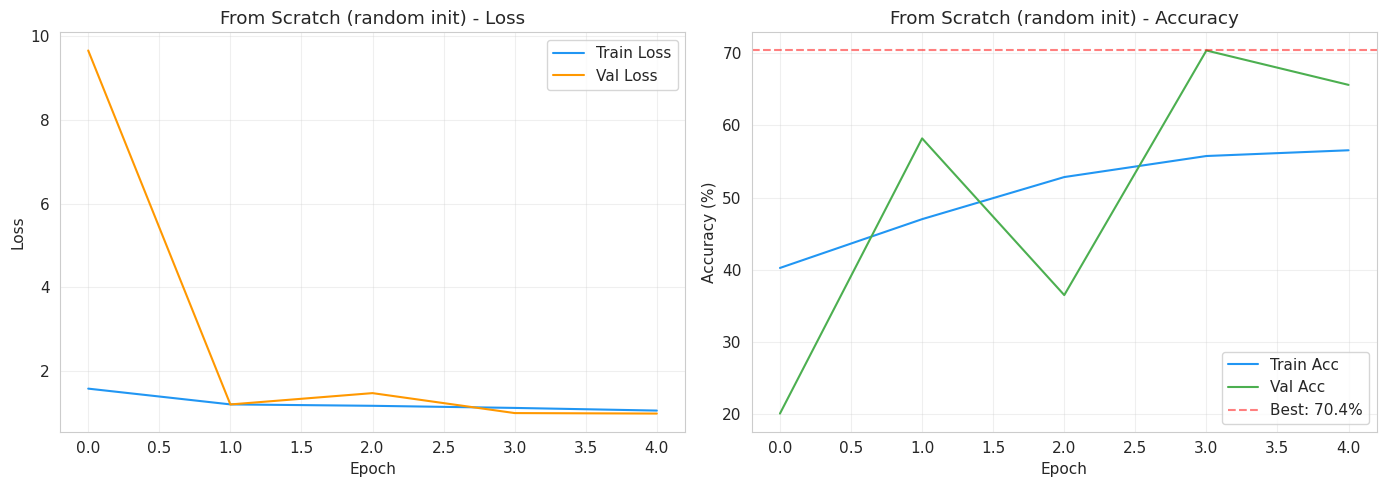

In [110]:
plot_training_curves(history_scratch, title='From Scratch (random init)')

With random initialization and only ~760 training images, the model overfits quickly. Training accuracy climbs but validation accuracy plateaus or drops. 11.7 million parameters trying to learn visual features from 760 images - there's simply not enough data to fill that capacity.

Compare this to our custom CNN from L11 which had only 394K parameters and reached ~81%. Sometimes a smaller model from scratch beats a larger one that can't fill its capacity. This is the bias-variance tradeoff in action: a model with too many parameters relative to its training data memorizes instead of generalizing.

But what if those 11.7 million parameters started from a useful place instead of random noise?

### Feature Extraction (Linear Probing): Freeze Backbone, Train Head Only

Now the same ResNet-18, but starting from ImageNet weights with the backbone frozen. Only the new 5-class head will train. This is also called **linear probing** in the research literature.

In [111]:
model_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_frozen.parameters():
    param.requires_grad = False

num_ftrs = model_frozen.fc.in_features
model_frozen.fc = nn.Linear(num_ftrs, NUM_CLASSES)
model_frozen = model_frozen.to(device)

trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_frozen.parameters())
print(f"Trainable parameters: {trainable:,} out of {total:,} ({trainable/total*100:.2f}%)")

Trainable parameters: 2,565 out of 11,179,077 (0.02%)


**A subtlety about freezing:** `requires_grad = False` stops gradient-based weight updates. But BatchNorm layers also track running mean and variance during `model.train()` mode, and that still happens even with gradients disabled. For our small dataset this is mostly fine, but be aware of it.

**Another subtlety:** pretrained models were trained at 224x224. If your images are much smaller and you can't resize, frozen early layers may underperform since they learned features at a different scale.

In [112]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_frozen.fc.parameters(), lr=1e-3)

print("Training with frozen backbone (feature extraction)...")
history_frozen = train_model(model_frozen, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

Training with frozen backbone (feature extraction)...
Epoch   1/5  Train Loss: 1.1500  Acc: 0.595  |  Val Loss: 0.4986  Acc: 0.947 *
Epoch   3/5  Train Loss: 0.3690  Acc: 0.934  |  Val Loss: 0.1412  Acc: 0.989 *

Best validation accuracy: 0.995


With pretrained features, the head converges almost immediately - it's essentially learning a linear mapping from already-good features to class labels. Compare the speed and stability to the from-scratch baseline above.

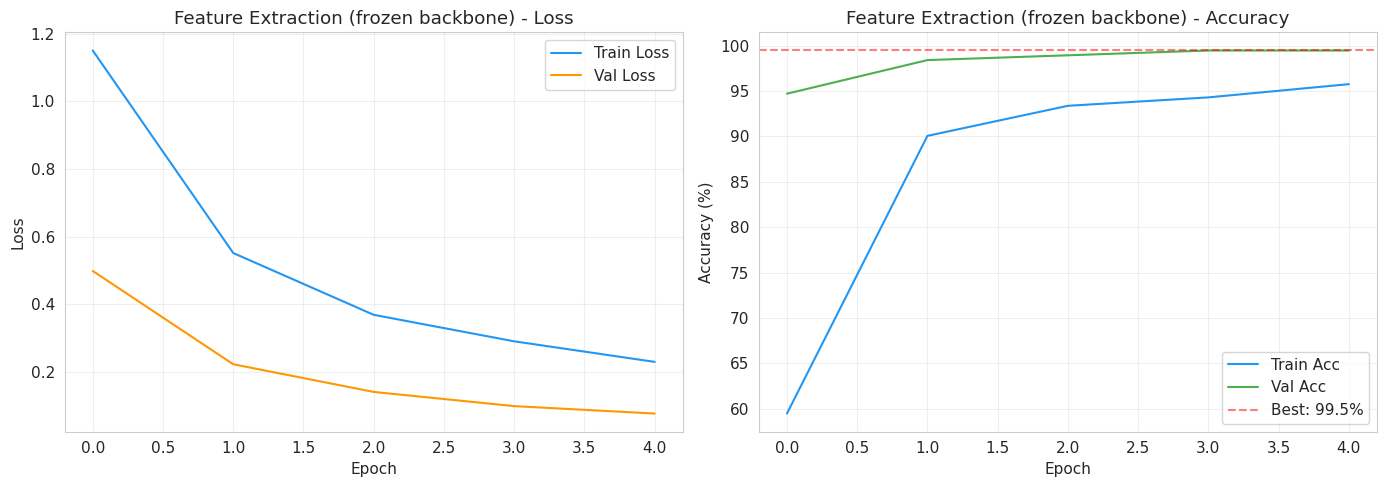

In [113]:
plot_training_curves(history_frozen, title='Feature Extraction (frozen backbone)')

### Full Fine-Tuning: Unfreeze Everything

Frozen feature extraction treats the backbone as a fixed feature extractor. But those features were learned from ImageNet - they're good, but not optimized for our specific task. Full fine-tuning lets the backbone adapt.

The critical detail: we use a **much lower learning rate** than training from scratch (1e-4 instead of 1e-3). Why? The pretrained weights are already in a good region of the loss landscape. Large updates would push them away from that region - destroying the useful features the model spent millions of images learning. Small updates let the model gently adjust while staying close to what it already knows.

This is the core tradeoff of fine-tuning: more flexibility (backbone adapts to your data) vs more risk (you might overwrite useful features).

In [114]:
model_finetune = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_finetune.fc = nn.Linear(model_finetune.fc.in_features, NUM_CLASSES)
model_finetune = model_finetune.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_finetune.parameters(), lr=1e-4)

print("Fine-tuning entire model...")
history_finetune = train_model(model_finetune, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

Fine-tuning entire model...
Epoch   1/5  Train Loss: 0.6152  Acc: 0.813  |  Val Loss: 0.0360  Acc: 0.995 *
Epoch   3/5  Train Loss: 0.0825  Acc: 0.979  |  Val Loss: 0.0087  Acc: 1.000 *

Best validation accuracy: 1.000


Notice how quickly fine-tuning converges compared to training from scratch. The loss starts much lower because the model already produces reasonable features - it's refining, not learning from zero.

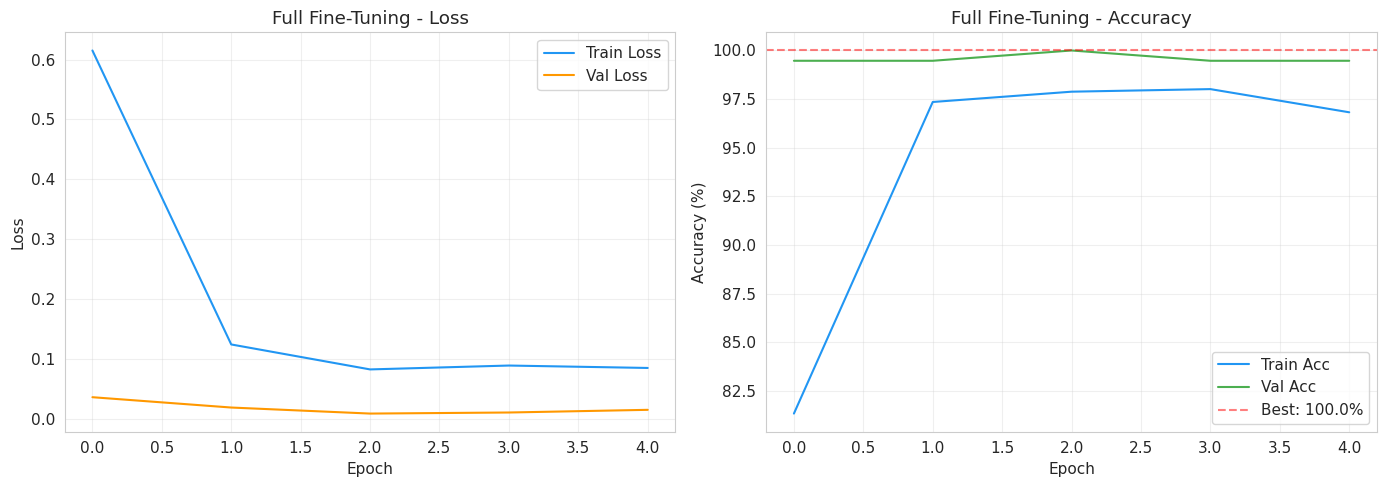

In [115]:
plot_training_curves(history_finetune, title='Full Fine-Tuning')

### What the Bird Results Tell Us

Our bird dataset has only 5 classes and ~950 images. With pretrained features, both frozen and fine-tuned models reach near-perfect accuracy. This is actually an important result:

**On small, simple tasks, pretraining is so powerful that the fine-tuning strategy barely matters.** Frozen backbone with 2,565 trainable parameters achieves the same accuracy as full fine-tuning with 11 million trainable parameters. The pretrained features are already good enough - no adaptation needed.

This has a practical implication: **start with the simplest approach (frozen backbone) and only add complexity if the results demand it.** On our birds, there's no reason to fine-tune the whole model. It's slower, uses more memory, and doesn't improve accuracy.

The question becomes: when DOES the strategy matter? When the task is harder. Let's set that up.

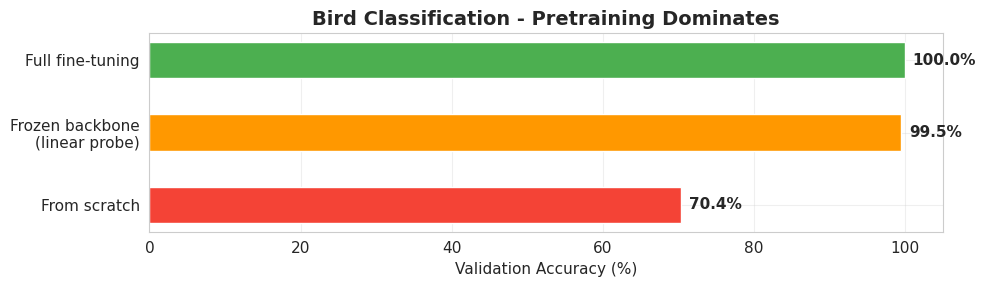


Strategy                        Val Acc   Trainable Params
------------------------------------------------------------
MLP from scratch (L9)            ~55.0%        ~25,000,000
CNN from scratch (L11)           ~81.0%           ~395,000
ResNet-18 random init             70.4%         11,179,077
ResNet-18 frozen                  99.5%              2,565
ResNet-18 fine-tuned             100.0%         11,179,077


In [116]:
results_birds = {
    'From scratch': max(history_scratch['val_acc']),
    'Frozen backbone\n(linear probe)': max(history_frozen['val_acc']),
    'Full fine-tuning': max(history_finetune['val_acc']),
}

plot_comparison_table(results_birds, title='Bird Classification - Pretraining Dominates')

print(f"\n{'Strategy':<30} {'Val Acc':>8} {'Trainable Params':>18}")
print("-" * 60)
print(f"{'MLP from scratch (L9)':<30} {'~55.0%':>8} {'~25,000,000':>18}")
print(f"{'CNN from scratch (L11)':<30} {'~81.0%':>8} {'~395,000':>18}")
print(f"{'ResNet-18 random init':<30} {max(history_scratch['val_acc'])*100:>7.1f}% {'11,179,077':>18}")
print(f"{'ResNet-18 frozen':<30} {max(history_frozen['val_acc'])*100:>7.1f}% {'2,565':>18}")
print(f"{'ResNet-18 fine-tuned':<30} {max(history_finetune['val_acc'])*100:>7.1f}% {'11,179,077':>18}")

### Saving and Loading Your Model

We've been keeping the best weights in memory, which is fine for quick experiments. But what if you want to use this model later - in another notebook, a FastAPI endpoint, or on a different machine?

The standard approach: save the `state_dict` (a dictionary of parameter names to tensors) to a `.pth` file. The architecture lives in your code, the weights live in the file.

In [117]:
# Save the best fine-tuned model to disk
save_path = 'best_bird_classifier.pth'
torch.save(model_finetune.state_dict(), save_path)
print(f"Saved to {save_path}")
print(f"File size: {Path(save_path).stat().st_size / 1e6:.1f} MB")

Saved to best_bird_classifier.pth
File size: 44.8 MB


To load it back, recreate the exact same architecture first, then fill in the weights:

In [118]:
# Load in a fresh session (or a different script entirely)
loaded_model = models.resnet18(weights=None)         # 1. recreate architecture (no pretrained weights)
loaded_model.fc = nn.Linear(512, NUM_CLASSES)         # 2. must match the head we trained
loaded_model.load_state_dict(                         # 3. load saved weights
    torch.load(save_path, weights_only=True)
)
loaded_model.eval()                                   # 4. switch to inference mode

# Verify it works
loaded_model = loaded_model.to(device)
_, test_acc = evaluate(loaded_model, val_loader, nn.CrossEntropyLoss(), device)
print(f"Loaded model accuracy: {test_acc:.3f}")

Loaded model accuracy: 1.000


Two things to always remember:
- The architecture must match exactly (same layers, same sizes) or `load_state_dict` will error
- Always call `model.eval()` before inference - it changes how BatchNorm and Dropout behave

We'll use the `save_path` parameter of our training function during the Flowers102 experiment later, where training takes longer and checkpointing to disk makes more sense. A deeper dive into export formats (ONNX, TorchScript) and model serving is planned for a dedicated deployment notebook.

### Different Backbone: EfficientNet-B0

Transfer learning isn't tied to ResNet. Any pretrained CNN works the same way: load weights, replace head, train. Let's try EfficientNet-B0, a more modern architecture that achieves better accuracy per parameter than ResNet by simultaneously scaling network width, depth, and resolution.

One practical gotcha: different architectures structure their classification heads differently. You can't blindly do `model.fc = nn.Linear(...)` on every model - you need to find where the head actually lives.

In [119]:
model_eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's head is NOT model.fc - it's model.classifier[1]
print("EfficientNet head structure:")
print(model_eff.classifier)
print(f"\nHead is model.classifier[1], not model.fc!")

# Replace the head
num_ftrs = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
print(f"\nReplaced: {num_ftrs} -> {NUM_CLASSES} classes")
print(f"Parameters: {sum(p.numel() for p in model_eff.parameters()):,}")

EfficientNet head structure:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Head is model.classifier[1], not model.fc!

Replaced: 1280 -> 5 classes
Parameters: 4,013,953


Different architecture, same pipeline. The only thing that changed was where the head lives. Always inspect the model structure with `print(model)` before replacing layers. We skip training EfficientNet here since the bird dataset is saturated - the important lesson is knowing how to adapt different architectures.

### The Two-Phase Recipe in Practice

We've tried frozen backbone and full fine-tuning as separate experiments. The standard production recipe combines them sequentially on the same model:

1. Freeze backbone, train head for a few epochs (head learns to use pretrained features)
2. Unfreeze backbone, continue with lower learning rate (backbone adapts while head refines)

This is what fastai's `learn.fine_tune()` does internally. The key advantage over jumping straight to full fine-tuning: the head starts from a trained state in Phase 2, so the gradients flowing back into the backbone are meaningful rather than random.

Let's implement both phases on the same model instance:

In [120]:
# Phase 1: Freeze backbone, train head
model_staged = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_staged.parameters():
    param.requires_grad = False
model_staged.fc = nn.Linear(model_staged.fc.in_features, NUM_CLASSES)
model_staged = model_staged.to(device)

optimizer_p1 = optim.Adam(model_staged.fc.parameters(), lr=1e-3)
print("Phase 1: Training head only...")
history_p1 = train_model(model_staged, train_loader, val_loader, nn.CrossEntropyLoss(), optimizer_p1, device, num_epochs=3)

Phase 1: Training head only...
Epoch   1/3  Train Loss: 1.3111  Acc: 0.522  |  Val Loss: 0.5876  Acc: 0.952 *
Epoch   3/3  Train Loss: 0.4180  Acc: 0.927  |  Val Loss: 0.1428  Acc: 1.000 *

Best validation accuracy: 1.000


Now unfreeze and continue with lower learning rate and discriminative LR (different rates per layer group):

In [121]:
# Phase 2: Unfreeze all, discriminative LR
for param in model_staged.parameters():
    param.requires_grad = True

optimizer_p2 = optim.Adam([
    {'params': [p for n, p in model_staged.named_parameters() if 'fc' not in n], 'lr': 1e-5},
    {'params': model_staged.fc.parameters(), 'lr': 1e-4},
])

print("Phase 2: Fine-tuning all layers with discriminative LR...")
history_p2 = train_model(model_staged, train_loader, val_loader, nn.CrossEntropyLoss(), optimizer_p2, device, num_epochs=5)

Phase 2: Fine-tuning all layers with discriminative LR...
Epoch   1/5  Train Loss: 0.3145  Acc: 0.936  |  Val Loss: 0.0792  Acc: 1.000 *
Epoch   3/5  Train Loss: 0.1908  Acc: 0.964  |  Val Loss: 0.0375  Acc: 1.000 *

Best validation accuracy: 1.000


On our easy bird dataset, this produces the same result as simpler approaches. The two-phase recipe shines on harder tasks with more data and classes. Let's see that now.

## Does Pretraining Source Matter?

Our bird dataset is too easy - every pretrained model saturates it. This tells us something important (pretraining dominates on simple tasks), but it can't answer the more nuanced question: does it matter WHERE the model was pretrained?

To test this, we need a genuinely hard task. **Flowers102** has 102 flower species and only ~2,000 training images. Many species look nearly identical - subtle differences in petal shape, color gradient, or leaf texture are what distinguish them. This is **fine-grained classification**, and it's where pretraining source should matter most.

We compare three ConvNeXt Nano models - same architecture, different starting weights. This controls for architecture differences, though the scratch model uses a higher learning rate and the IN-12k checkpoint also saw IN-1k data. It's a practical comparison, not a rigorous ablation.

Note: the specific IN-12k checkpoint (`convnext_nano.in12k_ft_in1k`) was first pretrained on ImageNet-12k (11,821 classes including many plant species) then further fine-tuned on ImageNet-1k. So it's had exposure to a broader set of visual categories than the IN-1k-only model.

In [122]:
from torchvision.datasets import Flowers102
from torch.utils.data import ConcatDataset, random_split

flowers_train_raw = Flowers102(root='./data', split='train', download=True, transform=train_transforms)
flowers_val_raw = Flowers102(root='./data', split='val', download=True, transform=train_transforms)
flowers_test = Flowers102(root='./data', split='test', download=True, transform=val_transforms)

# Combine train+val, then split properly into train and validation
flowers_combined = ConcatDataset([flowers_train_raw, flowers_val_raw])
fl_train_size = int(0.85 * len(flowers_combined))
fl_val_size = len(flowers_combined) - fl_train_size
flowers_train, flowers_val = random_split(flowers_combined, [fl_train_size, fl_val_size],
                                           generator=torch.Generator().manual_seed(42))

NUM_FLOWER_CLASSES = 102
flowers_train_loader = DataLoader(flowers_train, batch_size=32, shuffle=True, num_workers=2)
flowers_val_loader = DataLoader(flowers_val, batch_size=32, shuffle=False, num_workers=2)
flowers_test_loader = DataLoader(flowers_test, batch_size=32, shuffle=False, num_workers=2)

print(f"Flowers102: {len(flowers_train)} train, {len(flowers_val)} val, {len(flowers_test)} test, {NUM_FLOWER_CLASSES} classes")
print("Using val set for model selection, test set for final evaluation only.")

Flowers102: 1734 train, 306 val, 6149 test, 102 classes
Using val set for model selection, test set for final evaluation only.


We use `timm` (PyTorch Image Models) to access models with different pretraining sources. `timm` is an open-source library with 800+ pretrained model architectures - far more than torchvision's built-in collection. It includes models pretrained on ImageNet-1k, ImageNet-21k, ImageNet-12k, and other datasets.

The API is simple: `timm.create_model('model_name', pretrained=True, num_classes=N)` handles loading weights and replacing the head in one call.

Note: the scratch model uses a higher learning rate (1e-3 vs 1e-4) since it has no pretrained knowledge to preserve.

In [123]:
import timm

model_fl_scratch = timm.create_model('convnext_nano.d1h_in1k', pretrained=False, num_classes=NUM_FLOWER_CLASSES).to(device)
model_fl_in1k = timm.create_model('convnext_nano.d1h_in1k', pretrained=True, num_classes=NUM_FLOWER_CLASSES).to(device)
model_fl_in12k = timm.create_model('convnext_nano.in12k_ft_in1k', pretrained=True, num_classes=NUM_FLOWER_CLASSES).to(device)

print(f"Three ConvNeXt Nano models loaded (same architecture, different pretraining)")
print(f"Parameters per model: {sum(p.numel() for p in model_fl_scratch.parameters()):,}")

Three ConvNeXt Nano models loaded (same architecture, different pretraining)
Parameters per model: 15,017,942


Training all three models with the same number of epochs. Watch the learning curves - the from-scratch model should learn much more slowly because it has to discover features that the pretrained models already have.

In [124]:
results_flowers = {}

for name, model, lr in [
    ('No pretraining', model_fl_scratch, 1e-3),
    ('ImageNet-1k', model_fl_in1k, 1e-4),
    ('ImageNet-12k (via IN-1k)', model_fl_in12k, 1e-4),
]:
    print(f"\nTraining: ConvNeXt Nano ({name}), lr={lr}...")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_acc': [], 'val_acc': []}
    best_val = 0
    ckpt_path = f'flowers_{name.replace(" ", "_").lower()}.pth'
    
    for epoch in range(10):
        model.train()
        correct, total = 0, 0
        for images, labels in flowers_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            nn.CrossEntropyLoss()(out, labels).backward()
            optimizer.step()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        
        # Validate on val set (NOT test set)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in flowers_val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                correct += (out.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), ckpt_path)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/10  Train: {train_acc:.3f}  Val: {val_acc:.3f}")
    
    # Restore best model (selected on val), evaluate on test set
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in flowers_test_loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
    test_acc = correct / total
    
    results_flowers[name] = (test_acc, best_val, history)
    print(f"  Best val accuracy: {best_val:.3f}")
    print(f"  Final test accuracy: {test_acc:.3f}")


Training: ConvNeXt Nano (No pretraining), lr=0.001...
  Epoch  5/10  Train: 0.082  Val: 0.114
  Epoch 10/10  Train: 0.138  Val: 0.150
  Best val accuracy: 0.150
  Final test accuracy: 0.136

Training: ConvNeXt Nano (ImageNet-1k), lr=0.0001...
  Epoch  5/10  Train: 0.955  Val: 0.915
  Epoch 10/10  Train: 0.978  Val: 0.918
  Best val accuracy: 0.922
  Final test accuracy: 0.939

Training: ConvNeXt Nano (ImageNet-12k (via IN-1k)), lr=0.0001...
  Epoch  5/10  Train: 0.959  Val: 0.931
  Epoch 10/10  Train: 0.964  Val: 0.941
  Best val accuracy: 0.948
  Final test accuracy: 0.971


Time to compare. The bar chart shows final accuracy, but the learning curves are equally important - they show how quickly each model converges and whether the gap grows or shrinks over training.

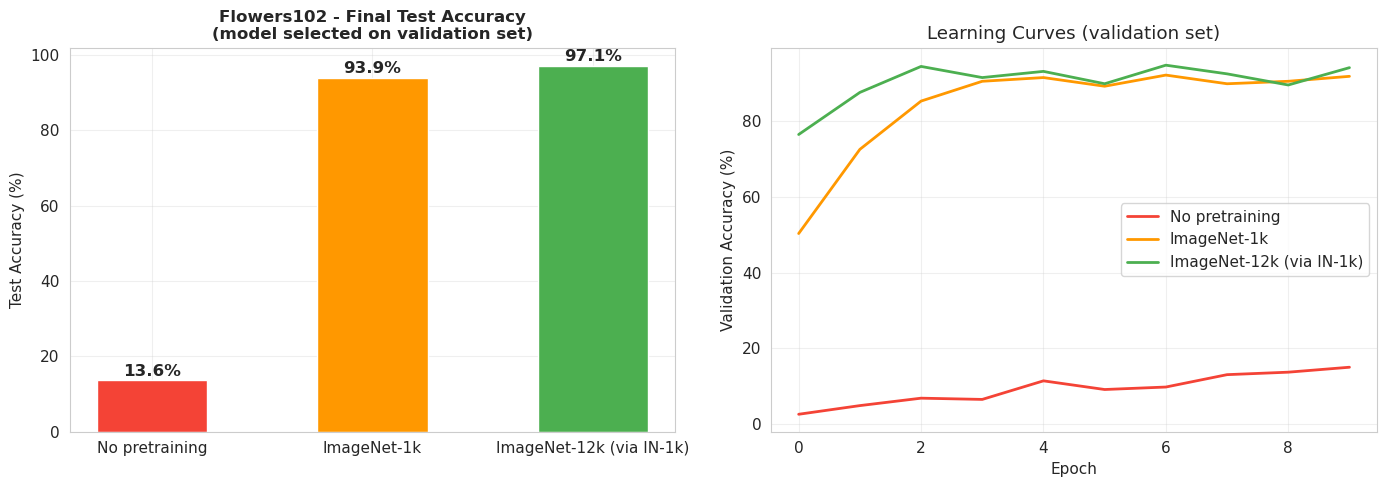

Pretraining               Classes seen     Best Val   Test Acc
--------------------------------------------------------------
No pretraining            0                   15.0%      13.6%
ImageNet-1k               1,000               92.2%      93.9%
ImageNet-12k (via IN-1k)  11,821+1,000        94.8%      97.1%


In [125]:
names = list(results_flowers.keys())
test_accs = [v[0] * 100 for v in results_flowers.values()]
val_accs = [v[1] * 100 for v in results_flowers.values()]
colors = ['#F44336', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(names, test_accs, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Flowers102 - Final Test Accuracy\n(model selected on validation set)', fontsize=12, fontweight='bold')
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for name, color in zip(names, colors):
    h = results_flowers[name][2]
    axes[1].plot([a*100 for a in h['val_acc']], label=name, color=color, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Learning Curves (validation set)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Pretraining':<25} {'Classes seen':<14} {'Best Val':>10} {'Test Acc':>10}")
print("-" * 62)
for name, (test_acc, val_acc, _) in results_flowers.items():
    classes = {'No pretraining': '0', 'ImageNet-1k': '1,000', 'ImageNet-12k (via IN-1k)': '11,821+1,000'}[name]
    print(f"{name:<25} {classes:<14} {val_acc*100:>9.1f}% {test_acc*100:>9.1f}%")

**What Flowers102 reveals that birds couldn't:**

Pretraining vs no pretraining is still the biggest gap by far. On 102 flower species with ~2,000 images, random initialization barely learns - the task is simply too hard to learn visual features from scratch with this little data.

Between IN-1k and IN-12k: the model exposed to more fine-grained categories during pretraining shows a small improvement. The gap is modest (and would need multiple runs to confirm it's not noise), but it's directionally consistent with the hypothesis that broader pretraining helps on fine-grained tasks.

Note the proper evaluation: we selected the best model using the validation set, then reported final accuracy on a held-out test set the model never saw during training or selection. This is the correct way to evaluate - using the test set for model selection (as some tutorials do) gives an optimistic estimate.

**The practical takeaway:** ImageNet-1k is a strong default for most tasks. But when working on fine-grained classification, look for models pretrained on broader datasets. The `timm` library makes this easy: `timm.list_models('*in12k*', pretrained=True)` shows what's available.

**A broader principle:** the closer your pretraining source is to your target task - in visual style, object types, and label granularity - the better transfer learning works. This is why domain-specific pretrained models (medical, satellite, industrial) exist and often outperform generic ImageNet models on their target domains.

## Object Detection

Object detection (YOLO) is covered in a separate notebook: `object_detection.ipynb`. It builds on the transfer learning concepts from this lesson but focuses on detecting and localizing multiple objects in an image.

## Questionnaire

Test your understanding:

1. What's the difference between feature extraction (linear probing) and fine-tuning?
2. Why do we use ImageNet normalization statistics instead of computing our own?
3. Why should early layers have a lower learning rate than later layers when fine-tuning?
4. Why does fine-tuning a pretrained model beat training from scratch, especially on small datasets?
5. How do you replace the classification head for ResNet vs EfficientNet? Why is it different?
6. In the two-phase training recipe, why do we train the head first before unfreezing?
7. What is negative transfer and when might it occur?
8. Why did broader pretraining (ImageNet-12k) help on Flowers102?
9. What does `requires_grad = False` do, and what does it NOT do (hint: BatchNorm)?
10. When should you look for a domain-specific pretrained model instead of using ImageNet?

## Further Research

- **GradCAM visualization** - see which parts of an image the model focuses on (Chapter 18 of the fastai book)
- **Gradual unfreezing** - instead of unfreezing everything at once, unfreeze one layer group at a time
- **Self-supervised pretraining** - what if your data looks nothing like ImageNet? Techniques like rotation prediction or contrastive learning let you pretrain on unlabeled domain data
- **Vision Transformers (ViT)** - CNNs aren't the only game anymore. Transformers work on images too.
- **Object detection** - see the `object_detection.ipynb` notebook in this folder
- **ONNX export** - convert your model to a framework-agnostic format for production deployment

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
&copy; 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>